# Datenanalyse mit SQL & Python - Tag 5: Übungen

**Freitag:** Abschlussprojekt & Storytelling mit Daten  
**Warm-up:** 30 Minuten EDA mit Household-Budget-Daten  
**Vormittag:** Data Storytelling - Ergebnisse klar und überzeugend präsentieren  
**Nachmittag:** Gruppenprojekt mit messy data: von der Business-Frage zur Empfehlung


## Lernziele

In diesen Übungen trainierst du:

- eine schnelle EDA mit einem bekannten Datensatz durchzuführen
- Analyseergebnisse in eine verständliche Datenstory zu übersetzen
- im Rollenspiel Business-Fragen und KPIs zu definieren
- ein messy Dataset eigenständig zu bereinigen
- mit SQL und Python Analysefragen zu beantworten
- Erkenntnisse und Empfehlungen klar zu präsentieren


## Hinweis zum Ablauf

Der vollständige Tagesablauf steht im Hauptnotebook `Day_5_Data_Analytics_SQL_Python.ipynb`.

Dieses Übungsnotebook enthält die konkreten Arbeitsaufträge für Warm-up, Storytelling-Übungen und Gruppenprojekt.


## Einrichtung & Importe

Führe diese Zelle zuerst aus. Sie lädt das Household Budget für den Warm-up und bereitet die Quellen für das Gruppenprojekt vor.


In [2]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)


BUDGET_PATH = 'https://raw.githubusercontent.com/chiaoya/Data_to_Decision_with_SQL_Python/refs/heads/main/course_data/household_budget.csv'

budget_df = pd.read_csv(BUDGET_PATH)
budget_df['date'] = pd.to_datetime(budget_df['date'])
budget_df['month'] = budget_df['date'].dt.strftime('%Y-%m')

conn = sqlite3.connect(':memory:')
budget_df.to_sql('budget', conn, index=False, if_exists='replace')


MESSY_PROJECT_DATASETS = {
    'Warehouse': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/warehouse_messy_data.csv',
    'IMDB': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/messy_IMDB_dataset.csv',
    'Healthcare': 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/healthcare_messy_data.csv',
}

print('budget_df:', budget_df.shape)
budget_df.head()


budget_df: (60, 6)


,date,category,description,amount,type,month
0,2024-02-01,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13,Utilities,Utilities payment,-227,Expense,2024-03


## Teil A: 30-Minuten Warm-up - EDA mit Household Budget

In diesem Warm-up geht es nicht um Data Cleaning. Der Datensatz ist bekannt und sauber genug. Ziel ist, schnell wieder in die Analyse-Logik zu kommen:

- Daten verstehen
- Kennzahlen berechnen
- Gruppen vergleichen
- ein Diagramm erstellen
- Erkenntnisse formulieren


### Übung A1: Überblick (ca. 5 Minuten)

**Aufgabe:** Prüfe Form, Spalten, Datentypen und erste Zeilen.


In [3]:
print('Form:', budget_df.shape)
print('Spalten:', budget_df.columns.tolist())
budget_df.info()
budget_df.head()


Form: (60, 6)
Spalten: ['date', 'category', 'description', 'amount', 'type', 'month']
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         60 non-null     datetime64[us]
 1   category     60 non-null     str           
 2   description  60 non-null     str           
 3   amount       60 non-null     int64         
 4   type         60 non-null     str           
 5   month        60 non-null     str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 2.9 KB


,date,category,description,amount,type,month
0,2024-02-01,Entertainment,Entertainment payment,-265,Expense,2024-02
1,2024-01-19,Rent,Rent payment,-191,Expense,2024-01
2,2024-03-09,Transport,Transport payment,-196,Expense,2024-03
3,2024-02-18,Dining,Dining payment,-173,Expense,2024-02
4,2024-03-13,Utilities,Utilities payment,-227,Expense,2024-03


### Übung A2: Zentrale Kennzahlen (ca. 7 Minuten)

**Aufgabe:** Berechne Gesamtausgaben, Gesamteinnahmen und Netto-Betrag.


In [4]:
total_expenses = budget_df.loc[budget_df['type'] == 'Expense', 'amount'].sum()
total_income = budget_df.loc[budget_df['type'] == 'Income', 'amount'].sum()
net_amount = budget_df['amount'].sum()

print('Gesamtausgaben:', total_expenses)
print('Gesamteinnahmen:', total_income)
print('Netto-Betrag:', net_amount)


Gesamtausgaben: -7934
Gesamteinnahmen: 21537
Netto-Betrag: 13603


### Übung A3: Ausgaben nach Kategorie (ca. 8 Minuten)

**Aufgabe:** Welche Kategorien verursachen die höchsten Ausgaben?


In [5]:
expenses_by_category = (
    budget_df[budget_df['type'] == 'Expense']
    .groupby('category')['amount']
    .sum()
    .abs()
    .sort_values(ascending=False)
)
expenses_by_category


category
Dining           2237
Entertainment    1812
Rent             1352
Utilities        1081
Transport         784
Groceries         668
Name: amount, dtype: int64

### Übung A4: Monatsanalyse (ca. 5 Minuten)

**Aufgabe:** Berechne den Netto-Betrag pro Monat.


In [6]:
monthly_budget = (
    budget_df
    .groupby('month')['amount']
    .sum()
    .reset_index(name='netto')
)
monthly_budget


,month,netto
0,2024-01,8985
1,2024-02,1991
2,2024-03,2627


### Übung A5: Visualisierung und Erkenntnisse (ca. 5 Minuten)

**Aufgabe:** Erstelle ein Diagramm und formuliere zwei kurze Erkenntnisse.


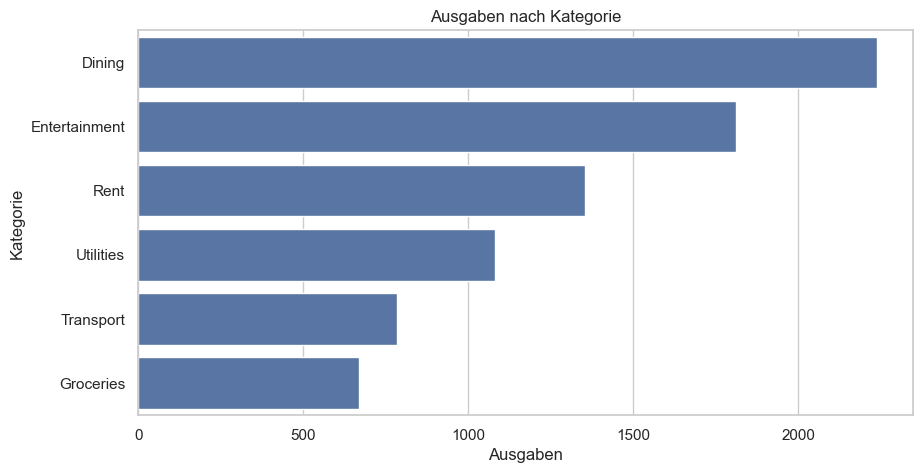

In [7]:
plot_data = expenses_by_category.reset_index()
plot_data.columns = ['category', 'expenses']

sns.barplot(data=plot_data, x='expenses', y='category')
plt.title('Ausgaben nach Kategorie')
plt.xlabel('Ausgaben')
plt.ylabel('Kategorie')
plt.show()


In [8]:
warmup_insights = [
    'Erkenntnis 1: ...',
    'Erkenntnis 2: ...'
]

for insight in warmup_insights:
    print('-', insight)


- Erkenntnis 1: ...
- Erkenntnis 2: ...


## Teil B: Data Storytelling - Übungsrahmen für den Vormittag

Der Input-Block dauert ungefähr zwei Stunden. Ziel ist nicht mehr Code, sondern bessere Kommunikation:

- Wer ist die Zielgruppe?
- Welche Entscheidung soll unterstützt werden?
- Welche Kennzahl ist zentral?
- Welches Diagramm passt zur Aussage?
- Welche Empfehlung folgt aus der Analyse?


### Übung B1: Von Analyse zu Storyline

Nutze das Household-Budget-Warm-up und fülle die Storyline aus.


In [ ]:
storyline = {
    'Zielgruppe': '...',
    'Entscheidung': '...',
    'Wichtigste Kennzahl': '...',
    'Zentrale Erkenntnis': '...',
    'Empfehlung': '...',
    'Nächster Schritt': '...'
}

for key, value in storyline.items():
    print(f'{key}: {value}')


### Übung B2: Diagramm bewusst auswählen

**Aufgabe:** Wähle für jede Aussage einen passenden Diagrammtyp.

| Aussage | Geeigneter Diagrammtyp |
|---|---|
| Vergleich von Kategorien | Balkendiagramm |
| Entwicklung über Zeit | Liniendiagramm |
| Verteilung einer Kennzahl | Histogramm oder Boxplot |
| Zusammenhang zweier Kennzahlen | Scatterplot |
| Anteil am Ganzen | gestapeltes Balkendiagramm oder vorsichtig Pie Chart |


### Übung B3: Präsentationssatz formulieren

**Aufgabe:** Formuliere einen Satz, der Zahl + Bedeutung + Empfehlung enthält.


In [ ]:
presentation_sentence = 'Die wichtigste Erkenntnis ist ..., deshalb empfehle ich ...'
print(presentation_sentence)


## Teil C: Gruppenprojekt - Messy Data Challenge am Nachmittag

Ihr arbeitet in Gruppen. Jede Gruppe wählt **einen** der drei noch nicht gemeinsam geübten Datensätze:

| Dataset | Quelle | Möglicher Business-Kontext |
|---|---|---|
| Warehouse | `warehouse_messy_data.csv` | Lagerbestand, Bestandrisiko, Nachbestellung |
| IMDB | `messy_IMDB_dataset.csv` | Filmportfolio, Ratings, Genres, Erfolgsfaktoren |
| Healthcare | `healthcare_messy_data.csv` | Patientendaten, Kosten, Wartezeit, Qualität |

Quelle: [`eyowhite/Messy-dataset`](https://github.com/eyowhite/Messy-dataset)


### Ablauf für 3 Stunden Gruppenarbeit

| Zeit | Aufgabe | Ergebnis |
|---|---|---|
| 30 Minuten | Role Play: Business + Data Analyst | KPIs und Analysefragen |
| 60 Minuten | Data Cleaning | `clean_df` + dokumentierte Cleaning-Entscheidungen |
| 30 Minuten | SQL-Fragen beantworten | 2-3 aggregierte Tabellen |
| 30 Minuten | Python EDA | 2-3 Diagramme |
| 30 Minuten | Findings & Recommendations | kurze Präsentation |

**Rollen:**

- Business-Rolle: formuliert Ziel, Entscheidung, KPIs und Prioritäten
- Data-Analyst-Rolle: prüft Daten, übersetzt Fragen in Analysen, erklärt Grenzen


### Schritt C1: Dataset wählen

Ändere `selected_project_dataset`, falls deine Gruppe ein anderes Thema wählt.


In [9]:
selected_project_dataset = 'Warehouse'  # Optionen: 'Warehouse', 'IMDB', 'Healthcare'
project_url = MESSY_PROJECT_DATASETS[selected_project_dataset]

project_raw = pd.read_csv(project_url, engine='python', on_bad_lines='warn')
print('Gewähltes Dataset:', selected_project_dataset)
print('Quelle:', project_url)
print('Form:', project_raw.shape)
project_raw.head()


Gewähltes Dataset: Warehouse
Quelle: https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/warehouse_messy_data.csv
Form: (1000, 10)


,Product ID,Product Name,Category,Warehouse,Location,Quantity,Price,Supplier,Status,Last Restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,NaN
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,two hundred,19.99,Supplier C,Out of Stock,NaN
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,two hundred,9.99,Supplier D,Out of Stock,25/04/2023


### Schritt C2: Role Play - Business und Data Analyst (30 Minuten)

**Aufgabe:** Führt ein kurzes Gespräch zwischen Business und Data Analyst.

**Business fragt:**

- Welche Entscheidung müssen wir treffen?
- Welche KPIs sind relevant?
- Welche Fragen sollen beantwortet werden?
- Was wäre eine nützliche Empfehlung?

**Data Analyst klärt:**

- Welche Spalten könnten die Frage beantworten?
- Welche Datenqualität ist kritisch?
- Welche Fragen sind realistisch in 3 Stunden?
- Welche Einschränkungen müssen kommuniziert werden?


In [10]:
business_context = '...'
decision_to_support = '...'

kpis = [
    'KPI 1: ...',
    'KPI 2: ...',
    'KPI 3: ...'
]

analysis_questions = [
    'Frage 1: ...',
    'Frage 2: ...',
    'Frage 3: ...'
]

print('Business-Kontext:', business_context)
print('Entscheidung:', decision_to_support)
print('KPIs:', kpis)
print('Analysefragen:', analysis_questions)


Business-Kontext: ...
Entscheidung: ...
KPIs: ['KPI 1: ...', 'KPI 2: ...', 'KPI 3: ...']
Analysefragen: ['Frage 1: ...', 'Frage 2: ...', 'Frage 3: ...']


### Schritt C3: Data Cleaning (60 Minuten)

**Aufgabe:** Erstelle `project_clean` und dokumentiere deine wichtigsten Cleaning-Entscheidungen.


In [11]:
project_clean = project_raw.copy()

# 1) Spaltennamen vereinheitlichen
project_clean.columns = (
    project_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

# 2) Textspalten bereinigen
text_cols = project_clean.select_dtypes(include=['object']).columns
for col in text_cols:
    project_clean[col] = project_clean[col].astype('string').str.strip()

# 3) Leere Strings in fehlende Werte umwandeln
project_clean = project_clean.replace(r'^\s*$', pd.NA, regex=True)

# 4) Duplikate entfernen
project_clean = project_clean.drop_duplicates()

print('Form vorher:', project_raw.shape)
print('Form nachher:', project_clean.shape)
project_clean.head()


Form vorher: (1000, 10)
Form nachher: (1000, 10)


/var/folders/g3/xwx5rk_j3vgg81zv4cx9701m0000gn/T/ipykernel_90387/2392253429.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = project_clean.select_dtypes(include=['object']).columns


,product_id,product_name,category,warehouse,location,quantity,price,supplier,status,last_restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,<NA>
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,two hundred,19.99,Supplier C,Out of Stock,<NA>
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,two hundred,9.99,Supplier D,Out of Stock,25/04/2023


In [12]:
cleaning_decisions = [
    'Cleaning-Entscheidung 1: ...',
    'Cleaning-Entscheidung 2: ...',
    'Cleaning-Entscheidung 3: ...'
]

for decision in cleaning_decisions:
    print('-', decision)


- Cleaning-Entscheidung 1: ...
- Cleaning-Entscheidung 2: ...
- Cleaning-Entscheidung 3: ...


### Schritt C4: SQL-Fragen beantworten (30 Minuten)

**Aufgabe:** Speichere `project_clean` in SQLite und beantworte 2-3 Fragen mit SQL.

Passe die Spaltennamen an dein Dataset an.


In [13]:
conn = sqlite3.connect(':memory:')
project_clean.to_sql('project_data', conn, index=False, if_exists='replace')

# Überblick über Spalten für SQL-Fragen
project_clean.columns.tolist()


['product_id',
 'product_name',
 'category',
 'warehouse',
 'location',
 'quantity',
 'price',
 'supplier',
 'status',
 'last_restocked']

In [14]:
query = '''
SELECT *
FROM project_data
LIMIT 10;
'''

sql_result_1 = pd.read_sql_query(query, conn)
sql_result_1


,product_id,product_name,category,warehouse,location,quantity,price,supplier,status,last_restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,NaN
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,two hundred,19.99,Supplier C,Out of Stock,NaN
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,two hundred,9.99,Supplier D,Out of Stock,25/04/2023
5,1071,widget b,CLOTHING,Warehouse 3,Aisle 5,300,NaN,Supplier A,In Stock,20/12/2022
6,1700,widget a,CLOTHING,Warehouse 2,Aisle 2,two hundred,49.99,Supplier B,In Stock,20/12/2022
7,1020,widget c,CLOTHING,Warehouse 1,Aisle 5,two hundred,9.99,Supplier D,Out of Stock,20/12/2022
8,1614,gadget y,ELECTRONICS,Warehouse 3,Aisle 3,300,9.99,Supplier B,Out of Stock,05/03/2023
9,1121,widget b,TOYS,Warehouse 1,Aisle 2,50,19.99,Supplier C,Out of Stock,20/12/2022


### Schritt C5: Python EDA (30 Minuten)

**Aufgabe:** Erstelle 2-3 EDA-Auswertungen mit Pandas und Visualisierungen.


In [15]:
# Numerische Spalten prüfen
numeric_project = project_clean.select_dtypes(include='number')
numeric_project.describe().T


,count,mean,std,min,25%,50%,75%,max
product_id,1000.0,1503.929000,289.998108,1000.00,1242.75,1505.00,1757.25,1998.00
price,793.0,28.085839,14.686312,9.99,19.99,29.99,49.99,49.99


In [16]:
# Kategoriale Spalten prüfen
categorical_project = project_clean.select_dtypes(include=['object', 'string'])
for col in categorical_project.columns[:5]:
    print()
    print(col)
    print(project_clean[col].value_counts(dropna=False).head(10))



product_name
product_name
gadget y    177
widget a    176
widget c    175
widget b    170
gadget z    169
gadget x    133
Name: count, dtype: Int64

category
category
FURNITURE      265
CLOTHING       257
ELECTRONICS    248
TOYS           230
Name: count, dtype: Int64

warehouse
warehouse
Warehouse 1    349
Warehouse 2    332
Warehouse 3    319
Name: count, dtype: Int64

location
location
Aisle 3    211
Aisle 1    210
Aisle 4    199
Aisle 5    199
Aisle 2    181
Name: count, dtype: Int64

quantity
quantity
300            177
150            175
50             169
100            161
two hundred    160
<NA>           158
Name: count, dtype: Int64


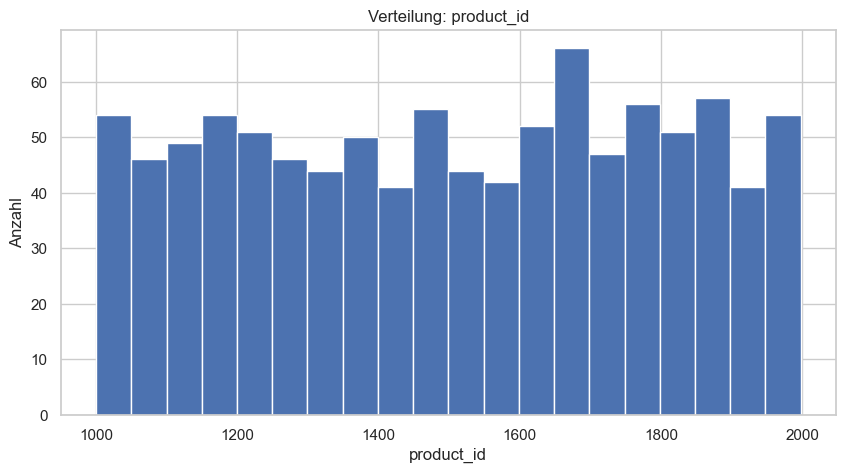

In [17]:
# Beispiel-Plot: erste numerische Spalte visualisieren
if len(numeric_project.columns) > 0:
    selected_col = numeric_project.columns[0]
    plt.hist(project_clean[selected_col].dropna(), bins=20)
    plt.title(f'Verteilung: {selected_col}')
    plt.xlabel(selected_col)
    plt.ylabel('Anzahl')
    plt.show()
else:
    print('Keine numerischen Spalten gefunden. Wählt eine kategoriale Analyse.')


### Schritt C6: Findings & Recommendations (30 Minuten)

**Aufgabe:** Verdichtet eure Analyse in eine kurze Präsentation.

Mindestens enthalten:

- Business-Frage
- Datenqualität: Was wurde bereinigt?
- 2-3 zentrale Findings
- 1-2 Empfehlungen
- Grenzen der Analyse
- Nächster Schritt


In [18]:
findings = [
    'Finding 1: ...',
    'Finding 2: ...',
    'Finding 3: ...'
]

recommendations = [
    'Empfehlung 1: ...',
    'Empfehlung 2: ...'
]

limitations = [
    'Grenze der Analyse: ...'
]

next_step = 'Nächster Schritt: ...'

for item in findings:
    print('-', item)
for item in recommendations:
    print('-', item)
for item in limitations:
    print('-', item)
print(next_step)


- Finding 1: ...
- Finding 2: ...
- Finding 3: ...
- Empfehlung 1: ...
- Empfehlung 2: ...
- Grenze der Analyse: ...
Nächster Schritt: ...


## Präsentations-Checkliste

Vor der Präsentation prüfen:

- Ist die Business-Frage klar?
- Sind die KPIs passend zur Frage?
- Sind Cleaning-Entscheidungen nachvollziehbar?
- Sind SQL- und Python-Ergebnisse konsistent?
- Unterstützen die Diagramme die Empfehlung?
- Werden Grenzen der Analyse ehrlich genannt?


## Abschlussreflexion

Diskutiert nach den Präsentationen:

1. Welche Gruppe hatte die klarste Business-Frage?
1. Welche Cleaning-Entscheidung war besonders wichtig?
1. Welche Visualisierung war am überzeugendsten?
1. Welche Empfehlung wäre in der Praxis direkt testbar?


## Musterlösungen

Diese Lösungen sind als Referenz gedacht. Im Gruppenprojekt sind mehrere richtige Wege möglich, solange Business-Frage, Cleaning, Analyse und Empfehlung nachvollziehbar zusammenpassen.


### Lösungen Teil A: EDA mit Household Budget

In [19]:
# A1
budget_df.head()
budget_df.info()

# A2
total_income = budget_df.loc[budget_df['type'] == 'Income', 'amount'].sum()
total_expenses = budget_df.loc[budget_df['type'] == 'Expense', 'amount'].sum()
net_amount = total_income - total_expenses

print('Income:', total_income)
print('Expenses:', total_expenses)
print('Net amount:', net_amount)

# A3
expenses_by_category = (
    budget_df
    .loc[budget_df['type'] == 'Expense']
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)
expenses_by_category

# A4
monthly_budget = (
    budget_df
    .assign(signed_amount=lambda df: np.where(df['type'] == 'Income', df['amount'], -df['amount']))
    .groupby('month')['signed_amount']
    .sum()
    .sort_index()
)
monthly_budget


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         60 non-null     datetime64[us]
 1   category     60 non-null     str           
 2   description  60 non-null     str           
 3   amount       60 non-null     int64         
 4   type         60 non-null     str           
 5   month        60 non-null     str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 2.9 KB
Income: 21537
Expenses: -7934
Net amount: 29471


month
2024-01    13695
2024-02     6637
2024-03     9139
Name: signed_amount, dtype: int64

In [ ]:
# A5
plot_data = expenses_by_category.reset_index()
plot_data.columns = ['category', 'amount']

sns.barplot(data=plot_data, x='amount', y='category')
plt.title('Ausgaben nach Kategorie')
plt.xlabel('Betrag')
plt.ylabel('Kategorie')
plt.show()

warmup_insights = [
    f'Groesste Ausgabenkategorie: {expenses_by_category.index[0]}',
    f'Gesamtausgaben: {total_expenses:.2f}',
    f'Netto-Betrag: {net_amount:.2f}',
]
warmup_insights


### Lösungen Teil B: Data Storytelling

In [20]:
storyline = {
    'business_question': 'Welche Ausgabenkategorie belastet das Budget am staerksten?',
    'main_finding': f'{expenses_by_category.index[0]} hat die hoechsten Ausgaben.',
    'evidence': f'Gesamtausgaben in dieser Kategorie: {expenses_by_category.iloc[0]:.2f}',
    'recommendation': 'Diese Kategorie zuerst pruefen und Einsparpotenzial priorisieren.',
}

storyline


{'business_question': 'Welche Ausgabenkategorie belastet das Budget am staerksten?',
 'main_finding': 'Groceries hat die hoechsten Ausgaben.',
 'evidence': 'Gesamtausgaben in dieser Kategorie: -668.00',
 'recommendation': 'Diese Kategorie zuerst pruefen und Einsparpotenzial priorisieren.'}

In [21]:
presentation_sentence = (
    f'Die wichtigste Erkenntnis ist, dass {expenses_by_category.index[0]} die groesste Ausgabenkategorie ist; '
    'deshalb empfehle ich, diese Kosten zuerst genauer zu analysieren.'
)

presentation_sentence


'Die wichtigste Erkenntnis ist, dass Groceries die groesste Ausgabenkategorie ist; deshalb empfehle ich, diese Kosten zuerst genauer zu analysieren.'

### Lösungen Teil C: Gruppenprojekt-Rahmen

In [22]:
selected_project_dataset = 'Warehouse'
project_raw = pd.read_csv(MESSY_PROJECT_DATASETS[selected_project_dataset], engine='python', on_bad_lines='warn')

project_clean = project_raw.copy()
project_clean.columns = (
    project_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

for col in project_clean.select_dtypes(include=['object']).columns:
    project_clean[col] = project_clean[col].astype('string').str.strip()

project_clean = project_clean.replace(r'^\s*$', pd.NA, regex=True)

cleaning_decisions = [
    'Spaltennamen vereinheitlicht',
    'Textwerte getrimmt',
    'Leere Strings als Missing Values markiert',
]

project_clean.head()


/var/folders/g3/xwx5rk_j3vgg81zv4cx9701m0000gn/T/ipykernel_90387/829610769.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in project_clean.select_dtypes(include=['object']).columns:


,product_id,product_name,category,warehouse,location,quantity,price,supplier,status,last_restocked
0,1102,gadget y,ELECTRONICS,Warehouse 2,Aisle 1,300,9.99,Supplier C,In Stock,<NA>
1,1435,gadget y,ELECTRONICS,Warehouse 2,Aisle 4,two hundred,19.99,Supplier C,Out of Stock,<NA>
2,1860,widget a,CLOTHING,Warehouse 2,Aisle 3,100,19.99,Supplier B,In Stock,20/12/2022
3,1270,gadget z,TOYS,Warehouse 2,Aisle 4,50,49.99,Supplier B,In Stock,20/12/2022
4,1106,widget a,FURNITURE,Warehouse 3,Aisle 3,two hundred,9.99,Supplier D,Out of Stock,25/04/2023


In [ ]:
# Beispielhafte SQL-Analyse fuer das Projekt
conn = sqlite3.connect(':memory:')
project_clean.to_sql('project', conn, index=False, if_exists='replace')

query = 'SELECT * FROM project LIMIT 10;'
pd.read_sql_query(query, conn)


In [ ]:
# Beispielhafte EDA fuer das Projekt
numeric_project = project_clean.select_dtypes(include='number')
categorical_project = project_clean.select_dtypes(include=['object', 'string'])

display(numeric_project.describe().T)
display(categorical_project.nunique().sort_values(ascending=False).head(10))

if len(numeric_project.columns) > 0:
    selected_col = numeric_project.columns[0]
    plt.hist(project_clean[selected_col].dropna(), bins=20)
    plt.title(f'Verteilung: {selected_col}')
    plt.xlabel(selected_col)
    plt.ylabel('Anzahl')
    plt.show()


In [ ]:
findings = [
    'Finding 1: Die Datenqualitaet beeinflusst die Aussagekraft der Analyse.',
    'Finding 2: Eine zentrale Kennzahl zeigt deutliche Unterschiede zwischen Gruppen.',
    'Finding 3: Weitere Daten wuerden die Empfehlung belastbarer machen.',
]

recommendations = [
    'Empfehlung 1: Auffaellige Gruppe genauer untersuchen.',
    'Empfehlung 2: Datenqualitaetsregeln fuer kuenftige Erfassung definieren.',
]

limitations = [
    'Grenze der Analyse: Missing Values und uneinheitliche Formate koennen Ergebnisse verzerren.',
]

next_step = 'Naechster Schritt: Analyse mit bereinigten Daten wiederholen und Ergebnis validieren.'

for item in findings + recommendations + limitations + [next_step]:
    print('-', item)
